In [20]:
import os
import pickle
import pandas as pd
from tqdm import tqdm
import numpy as np
from scipy.stats import zscore
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import PIL.Image as Image
import torchvision
import torchvision.transforms as transforms
import seaborn as sns
import BrainSOM
import Hopfield_VTCSOM

face_mask_VTC = np.load(r'face_mask.npy')
object_mask_VTC = np.load(r'object_mask.npy')


### Data
data_transforms = {
    'see': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224)]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                             std = [0.229, 0.224, 0.225])]),
    'val_resize': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                             std = [0.229, 0.224, 0.225])]),
    'see_flip': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomVerticalFlip(p=1)]),
    'flip': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomVerticalFlip(p=1),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                             std = [0.229, 0.224, 0.225])])
    }
        
alexnet = torchvision.models.alexnet(pretrained=True)
alexnet.eval()

d:\anaconda3\envs\occluded_face\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda3\envs\occluded_face\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [9]:
Data = np.load('Data.npy')
Data = zscore(Data)
pca = PCA()
pca.fit(Data)
    

# VTC SOM and model
som_VTC = BrainSOM.VTCSOM(200, 200, 4, sigma=6.2, learning_rate=1, neighborhood_function='gaussian')
som_VTC._weights = np.load('som_sigma_6.2.npy')

model_VTC = Hopfield_VTCSOM.Stochastic_Hopfield_nn(x=200, y=200, pflag=1, nflag=-1,
                                                   patterns=[None, None, None, None])
model_VTC._w = np.load('model_VTC_weights.npy')

In [10]:
# vlPFC SOM and model
som_vlPFC = BrainSOM.VTCSOM(20, 20, 40000, sigma=6, learning_rate=1, neighborhood_function='gaussian')
som_vlPFC._weights = np.load('som_vlPFC_weights.npy')

In [11]:
model_vlPFC = Hopfield_VTCSOM.Stochastic_Hopfield_nn(x=20, y=20, pflag=1, nflag=-1,
                                                     patterns=[None, None, None, None])
model_vlPFC._w = np.load('model_vlPFC_weights.npy')

w_vtc_to_vlpfc = som_vlPFC._weights
w_vlpfc_to_vtc = w_vtc_to_vlpfc.transpose(2,0,1).reshape(200,200,400)
som_vlpfc_to_vtc = BrainSOM.VTCSOM(200, 200, 400, sigma=6.2, learning_rate=1, neighborhood_function='gaussian')
som_vlpfc_to_vtc._weights = w_vlpfc_to_vtc

In [ ]:
def plot_6_condition_timeseries(mode, region, Dynamics_states):
    def stats_value1(x, region):
        face_timeseries = x[:,:,np.where(face_mask_VTC==1)[0], np.where(face_mask_VTC==1)[1]].mean(axis=2)
        object_timeseries = x[:,:,np.where(object_mask_VTC==1)[0], np.where(object_mask_VTC==1)[1]].mean(axis=2)
        return (face_timeseries-object_timeseries)/2
    def stats_value2(x, region):
        face_timeseries = x[:,:,np.where(face_mask_VTC==1)[0], np.where(face_mask_VTC==1)[1]].mean(axis=2)
        else_timeseries = x[:,:,np.where(face_mask_VTC==-1)[0], np.where(face_mask_VTC==-1)[1]].mean(axis=2)
        return (face_timeseries-else_timeseries)/2
    def stats_value3(x, region):
        if region=='face':
            mask = face_mask_VTC
        if region=='object':
            mask = object_mask_VTC
        timeseries = x[:,:,np.where(mask==1)[0], np.where(mask==1)[1]].mean(axis=2)
        return timeseries
    if mode=='single':
        stats_value = stats_value3
    if mode=='double':
        stats_value = stats_value1
    if mode=='multiple':
        stats_value = stats_value2
    # data
    images_response_face = stats_value(Dynamics_states[0], region)
    images_response_top = stats_value(Dynamics_states[1], region)
    images_response_noeye = stats_value(Dynamics_states[2], region)
    images_response_down = stats_value(Dynamics_states[3], region)
    images_response_eye = stats_value(Dynamics_states[4], region)
    # plot
    fig, ax = plt.subplots(figsize=(3,6), dpi=300)
    plt.rcParams['font.family'] = 'Arial'       # 设置全局字体为无衬线字体Arial
    plt.rcParams['font.size'] = 13              # 全局字体大小8pt（根据期刊要求调整）
    plt.rcParams['axes.linewidth'] = 1.5       # 坐标轴线宽1.5pt
    sns.set_style("ticks")
    ax.plot(range(images_response_face.shape[1]), images_response_face.mean(0),label='Intact',c='red')
    ax.fill_between(range(images_response_face.shape[1]),
                     images_response_face.mean(0)-(0.5*images_response_face.std(0)/np.sqrt(20)),
                     images_response_face.mean(0)+(0.5*images_response_face.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor='red')
    ax.plot(range(images_response_noeye.shape[1]), images_response_noeye.mean(0),label='Eyes-Oc.',c='blue')
    ax.fill_between(range(images_response_noeye.shape[1]),
                     images_response_noeye.mean(0)-(0.5*images_response_noeye.std(0)/np.sqrt(20)),
                     images_response_noeye.mean(0)+(0.5*images_response_noeye.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor='blue')
    ax.plot(range(images_response_top.shape[1]), images_response_top.mean(0),label='Upper-Half',c='green')
    ax.fill_between(range(images_response_top.shape[1]),
                     images_response_top.mean(0)-(0.5*images_response_top.std(0)/np.sqrt(20)),
                     images_response_top.mean(0)+(0.5*images_response_top.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor='green')
    ax.plot(range(images_response_down.shape[1]), images_response_down.mean(0),label='Lower-Half',c='purple')
    ax.fill_between(range(images_response_down.shape[1]),
                     images_response_down.mean(0)-(0.5*images_response_down.std(0)/np.sqrt(20)),
                     images_response_down.mean(0)+(0.5*images_response_down.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor='purple')
    ax.plot(range(images_response_eye.shape[1]), images_response_eye.mean(0),label='Eyes-Only',c='yellow')
    ax.fill_between(range(images_response_eye.shape[1]),
                     images_response_eye.mean(0)-(0.5*images_response_eye.std(0)/np.sqrt(20)),
                     images_response_eye.mean(0)+(0.5*images_response_eye.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor='yellow')
    ax.set_ylim([-1,1])
    ax.legend()
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.annotate('', 
                 xy=(1.1, 0), xycoords='axes fraction',
                 xytext=(-0.06, 0), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    # 绘制 y 轴方向的箭头
    ax.annotate('', 
                 xy=(0, 1.1), xycoords='axes fraction',
                 xytext=(0, -0.06), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    plt.show()

def plot_6_condition_bar_chart(Dynamics_states_VTC, mask, scatter=False):
    # data
    images_response_face = Dynamics_states_VTC[0][:, -1, np.where(mask==1)[0], np.where(mask==1)[1]].mean(axis=1)
    images_response_top = Dynamics_states_VTC[1][:, -1, np.where(mask==1)[0], np.where(mask==1)[1]].mean(axis=1)
    images_response_noeye = Dynamics_states_VTC[2][:, -1, np.where(mask==1)[0], np.where(mask==1)[1]].mean(axis=1)
    images_response_down = Dynamics_states_VTC[3][:, -1, np.where(mask==1)[0], np.where(mask==1)[1]].mean(axis=1)
    images_response_eye = Dynamics_states_VTC[4][:, -1, np.where(mask==1)[0], np.where(mask==1)[1]].mean(axis=1)
    # plot
    plt.figure(figsize=(4,4), dpi=400)
    plt.bar(range(6), [images_response_face.mean(), images_response_top.mean(), images_response_noeye.mean(),
                       images_response_down.mean(), images_response_eye.mean(), images_response_tool.mean()],
                      color=['red','green','blue','purple','yellow','black'])
    if scatter==True:
        plt.scatter(np.zeros(images_response_face.shape),images_response_face,marker='.',s=2, c='black')
        plt.scatter(np.ones(images_response_top.shape),images_response_top,marker='.',s=2, c='black')
        plt.scatter(2*np.ones(images_response_noeye.shape),images_response_noeye,marker='.',s=2, c='black')
        plt.scatter(3*np.ones(images_response_down.shape),images_response_down,marker='.',s=2, c='black')
        plt.scatter(4*np.ones(images_response_eye.shape),images_response_eye,marker='.',s=2, c='black')
    plt.errorbar(range(5), [images_response_face.mean(), images_response_top.mean(), images_response_noeye.mean(),
                            images_response_down.mean(), images_response_eye.mean(), images_response_tool.mean()], 
                           [images_response_face.std()/np.sqrt(20), images_response_top.std()/np.sqrt(20), images_response_noeye.std()/np.sqrt(20),
                            images_response_down.std()/np.sqrt(20), images_response_eye.std()/np.sqrt(20), images_response_tool.std()/np.sqrt(20)],
                linestyle='None', ecolor='black', elinewidth=1, capsize=2)
    plt.xticks(range(6), ('Face','Top_face','No_eye','Down_face','Eye','Tool'), rotation=70, fontsize=8)
    plt.ylim(-1.05,1.05)
    
from skimage.segmentation import find_boundaries

def save_feedback_gif(data1, data2, data3, save_name):
    fig = plt.figure(figsize=(18, 5))    
    cmap = mcolors.ListedColormap(['lightgrey', 'darkred'])  # 灰色和红色
    bounds = [-1, 0, 1]  # 色条边界
    norm = mcolors.BoundaryNorm(bounds, cmap.N)   
    ax1 = fig.add_subplot(131)
    ax2 = fig.add_subplot(132)
    ax3 = fig.add_subplot(133)
    img1 = ax1.imshow(data1[0], cmap=cmap, norm=norm)
    ax1.set_title('VTC')
    ax1.axis('off')  # 关闭坐标轴
    img2 = ax2.imshow(data2[0], cmap=cmap, norm=norm)
    ax2.set_title('vlPFC')
    ax2.axis('off')  # 关闭坐标轴
    img3 = ax3.imshow(data3[0], cmap=cmap, norm=norm)
    ax3.set_title('top-down')
    ax3.axis('off')  # 关闭坐标轴
    def update(frame):
        img1.set_data(data1[frame])
        img2.set_data(data2[frame])
        img3.set_data(data3[frame])
        return [img1, img2, img3]
    ani = FuncAnimation(fig, update, frames=121, interval=100, blit=True)
    ani.save(save_name)

def save_recurrent_gif(data, boundaries, save_name):
    fig, ax = plt.subplots(figsize=(6,6))
    cmap = mcolors.ListedColormap(['lightgrey', 'darkred'])  # 灰色和红色
    bounds = [-1, 0, 1]  # 色条边界
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    img = ax.imshow(data[0], cmap=cmap, norm=norm)
    ax.axis('off')  # 关闭坐标轴
    def update(frame):
        temp = data[frame]
        temp[boundaries==1] = 2
        img.set_data(temp)
        return [img]
    ani = FuncAnimation(fig, update, frames=data.shape[0], interval=100, blit=True)
    ani.save(save_name)

def load_Dynamics_state(file_dir, mode, key):
    results_dir = [file_dir+'Face_'+mode+'_results.npy',
                   file_dir+'Top_face_'+mode+'_results.npy',
                   file_dir+'Noeye_'+mode+'_results.npy',
                   file_dir+'Down_face_'+mode+'_results.npy',
                   file_dir+'Eyes_'+mode+'_results.npy']
    Dynamics_states_VTC = [np.load(i,allow_pickle=True)[key] for i in results_dir]
    return Dynamics_states_VTC

def one_way_ANOVA(data, alpha_ANOVA, alpha_tukey):
    from scipy.stats import f_oneway
    from statsmodels.stats.multicomp import MultiComparison
    import pandas as pd
    f_value, p_value = f_oneway(data[:,0], data[:,1], data[:,2], data[:,3], data[:,4])
    if p_value < alpha_ANOVA:
        mc = MultiComparison(np.hstack([d for d in data.T]),
                             np.hstack([np.ones(data.shape[0])*i for i in range(data.shape[1])]))
        df_smry = mc.tukeyhsd(alpha=alpha_tukey).summary()
        m = np.array(df_smry.data)
        df_p = pd.DataFrame(m[1:],columns=m[0])
        print(df_p)
    else:
        print('None results')

# vlPFC-VTC model

In [16]:
mean, std = np.load('mean.npy'), np.load('std.npy')

In [17]:
def minmax(s):
    return (s-s.min())/(s.max()-s.min())
def sampling(s):
    """s is a 200x200 or 20x20 state"""
    s = minmax(s)
    sample = (np.random.binomial(1,s,s.shape))
    sample = 2*sample - 1
    return sample

def stochastic_dynamics_one_region(model_VTC, state, beta, H_bottom_up, epochs, save_inter_step):
    # model state initialization
    if isinstance(state, list):
        state = np.asarray(state)
    model_VTC.dynamics_state = state.reshape(1, model_VTC._x,model_VTC._y)
    # neuron index
    indexs_VTC = np.random.randint(0, len(model_VTC._w) - 1, (epochs, len(state)))
    # initial top-down 
    H_external = H_bottom_up.reshape(model_VTC._x*model_VTC._y, 1)
    for step,ind_vtc in tqdm(enumerate(indexs_VTC)):
        # VTC
        diagonal = np.diagonal(np.dot(model_VTC._w[ind_vtc], state.T + H_external))
        diagonal = np.expand_dims(diagonal, -1)
        value = np.apply_along_axis(
            lambda x: model_VTC.pflag if model_VTC.stochastic_activation(beta, x)>np.random.uniform(0,1,1) else model_VTC.nflag, 1, diagonal)
        for i in range(len(state)):
            state[i, ind_vtc[i]] = value[i]
        if step % save_inter_step == 0:
            model_VTC.dynamics_state = np.vstack((model_VTC.dynamics_state, state.reshape(1,model_VTC._x,model_VTC._y)))
    model_VTC.state = state.reshape(model_VTC._x,model_VTC._y)
    return state

def stochastic_dynamics_two_regions(model_VTC, model_vlPFC, som_vlPFC, 
                                    state, beta, H_bottom_up, top_down_strength,
                                    epochs, interval, vlPFC_start_time, save_inter_step):
    # model state initialization
    if isinstance(state, list):
        state = np.asarray(state)
    model_VTC.dynamics_state = state.reshape(1, model_VTC._x,model_VTC._y)
    # vlPFC to VTC som
    w_vtc_to_vlpfc = som_vlPFC._weights
    w_vlpfc_to_vtc = w_vtc_to_vlpfc.transpose(2,0,1).reshape(200,200,400)
    som_vlpfc_to_vtc = BrainSOM.VTCSOM(200, 200, 400, sigma=6.2, learning_rate=1, neighborhood_function='gaussian')
    som_vlpfc_to_vtc._weights = w_vlpfc_to_vtc
    # neuron index
    indexs_VTC = np.random.randint(0, len(model_VTC._w) - 1, (epochs, len(state)))
    indexs_vlPFC = np.random.randint(0, len(model_vlPFC._w) - 1, (epochs, len(state)))
    # initial top-down 
    H_top_down = np.zeros((model_VTC._x * model_VTC._y, 1))
    # two regions update
    F = []
    H_top_down_all = []
    for step,ind in tqdm(enumerate(zip(indexs_VTC, indexs_vlPFC))):
        ind_vtc = ind[0]
        ind_vlpfc = ind[1]
        # VTC
        H_external = H_top_down + H_bottom_up.reshape(model_VTC._x*model_VTC._y, 1)
        diagonal = np.diagonal(np.dot(model_VTC._w[ind_vtc], state.T + H_external))
        diagonal = np.expand_dims(diagonal, -1)
        value = np.apply_along_axis(
            lambda x: model_VTC.pflag if model_VTC.stochastic_activation(beta, x)>np.random.uniform(0,1,1) else model_VTC.nflag, 1, diagonal)
        for i in range(len(state)):
            state[i, ind_vtc[i]] = value[i]
        if step % save_inter_step == 0:
            model_VTC.dynamics_state = np.vstack((model_VTC.dynamics_state, state.reshape(1,model_VTC._x,model_VTC._y)))
        if step == vlPFC_start_time:
            state_vlpfc = som_vlPFC.forward_activate((state[0]+1)/2)
            state_vlpfc = sampling(state_vlpfc)
            state_vlpfc = np.asarray([state_vlpfc.reshape(-1)])
            model_vlPFC.dynamics_state = state_vlpfc.reshape(1, model_vlPFC._x,model_vlPFC._y)            
        if step > vlPFC_start_time and step % interval == 0:
            # vlPFC
            H_from_VTC = som_vlPFC.forward_activate((state[0]+1)/2)
            H_from_VTC = H_from_VTC.reshape(model_vlPFC._x*model_vlPFC._y, 1)
            diagonal = np.diagonal(np.dot(model_vlPFC._w[ind_vlpfc], state_vlpfc.T + H_from_VTC))
            diagonal = np.expand_dims(diagonal, -1)
            value = np.apply_along_axis(
                lambda x: model_vlPFC.pflag if model_vlPFC.stochastic_activation(beta, x)>np.random.uniform(0,1,1) else model_vlPFC.nflag, 1, diagonal)
            for i in range(len(state_vlpfc)):
                state_vlpfc[i, ind_vlpfc[i]] = value[i]
            if step % save_inter_step == 0:
                model_vlPFC.dynamics_state = np.vstack((model_vlPFC.dynamics_state, state_vlpfc.reshape(1,model_vlPFC._x,model_vlPFC._y)))
            # update external
            H_top_down = som_vlpfc_to_vtc.forward_activate((state_vlpfc[0]+1)/2)
            H_top_down_all.append(H_top_down)
            H_top_down = np.where(H_top_down>np.percentile(H_top_down,70),1,-1) * top_down_strength
            H_top_down = H_top_down.reshape((model_VTC._x * model_VTC._y, 1))
    model_VTC.state = state.reshape(model_VTC._x,model_VTC._y)
    model_vlPFC.state = state_vlpfc.reshape(model_vlPFC._x,model_vlPFC._y)
    return state, np.array(F), np.array(H_top_down_all)

def Feedback_results(stim_file_path, mean, std):
    files = os.listdir(stim_file_path)
    Image_state_dict = dict()
    Dynamic_states_VTC = []
    Dynamic_states_vlPFC = []
    F_all = []
    H_top_down_all = []
    for index,f in enumerate(files):
        print(stim_file_path, str(index), f)
        model_VTC.rebuild_up_param()
        model_vlPFC.rebuild_up_param()
        pic_dir = stim_file_path + f
        img_see, img_mask_see, initial_s = Pure_picture_activation(pic_dir, 'val', som_VTC, 
                                                                       pca, [0,1,2,3], 
                                                                       mean, std)
        stable_state, F, H_top_down = stochastic_dynamics_two_regions(model_VTC, model_vlPFC, som_vlPFC,
                                                       [sampling(initial_s).reshape(-1)], beta=100,
                                                       H_bottom_up=initial_s, top_down_strength=4,
                                                       epochs=80000, interval=100, vlPFC_start_time=50000, save_inter_step=1000)
        dynamic_states_vtc = model_VTC.dynamics_state
        dynamic_states_vlpfc = model_vlPFC.dynamics_state        
        stable_state_new = stochastic_dynamics_one_region(model_VTC, [stable_state.reshape(-1)], beta=100,
                                                 H_bottom_up=np.zeros((200,200)), 
                                                 epochs=80000, save_inter_step=1000)
        plt.figure()
        plt.imshow(stable_state_new[0].reshape(200,200))
        plt.axis('off')
        plt.show()
        dynamic_states_vtc = np.vstack((dynamic_states_vtc, model_VTC.dynamics_state))
        F_all.append(F)
        H_top_down_all.append(H_top_down)
        Dynamic_states_VTC.append(dynamic_states_vtc)
        Dynamic_states_vlPFC.append(dynamic_states_vlpfc)
        Image_state_dict[index] = stable_state_new[0].reshape(200,200)
    images_response = []
    for k,v in Image_state_dict.items():
        images_response.append(v)
    images_response = np.array(images_response)
    Dynamic_states_VTC = np.array(Dynamic_states_VTC)
    Dynamic_states_vlPFC = np.array(Dynamic_states_vlPFC)
    return images_response, Dynamic_states_VTC, Dynamic_states_vlPFC, np.array(F_all), np.array(H_top_down_all)

def results_dic(inputs, mode):
    """images_response: VTC stable state for all images
       Dynamic_states_VTC: VTC dynamic states for all images
       Dynamic_states_vlPFC: vlPFC dynamic states for all images
       F_all: vlPFC top-down weights factor through time for all images, results by adaptation
       H_top_down_all: vlPFC to VTC top-down signal
    """
    if mode=='feedback':
        results = dict()
        Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all = inputs
        results['Dynamic_states_VTC'] = Dynamic_states_VTC
        results['Dynamic_states_vlPFC'] = Dynamic_states_vlPFC
        results['F'] = F_all
        results['H_top_down'] = H_top_down_all
    if mode=='recurrent':
        results = dict()
        Dynamic_states_VTC = inputs[0]
        results['Dynamic_states_VTC'] = Dynamic_states_VTC
    return results

Stim_for_model/face/ 0 face (1).png


80000it [03:33, 374.75it/s] 
80000it [01:56, 688.59it/s] 


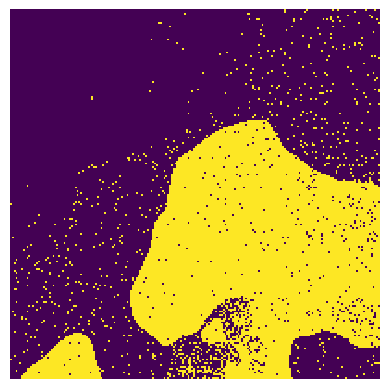

Stim_for_model/face/ 1 face (10).png


80000it [03:41, 361.73it/s]
80000it [02:13, 598.22it/s] 


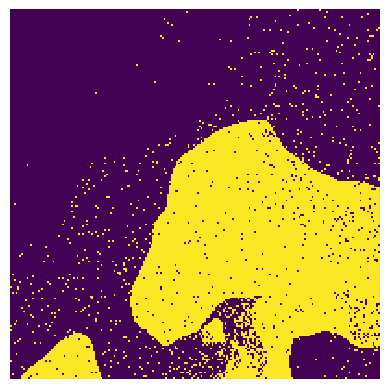

Stim_for_model/face/ 2 face (13).png


80000it [03:53, 343.07it/s]
80000it [02:22, 562.89it/s]


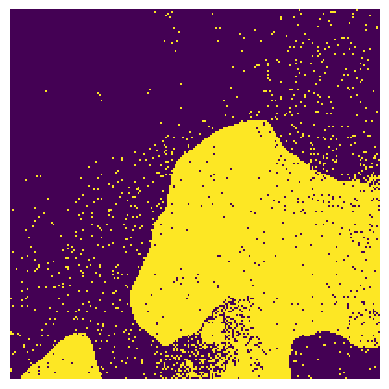

Stim_for_model/face/ 3 face (14).png


80000it [03:47, 351.66it/s]
80000it [02:12, 604.69it/s] 


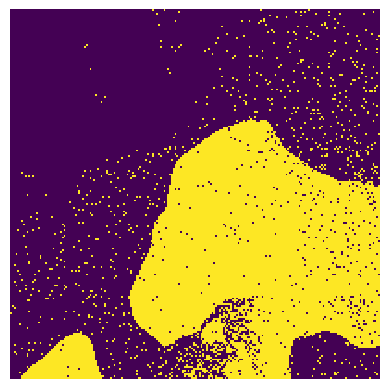

Stim_for_model/face/ 4 face (15).png


80000it [03:55, 339.24it/s]
80000it [02:29, 535.91it/s]


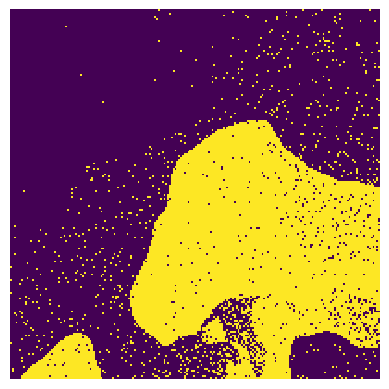

Stim_for_model/face/ 5 face (16).png


80000it [03:56, 337.98it/s]
80000it [02:24, 552.93it/s]


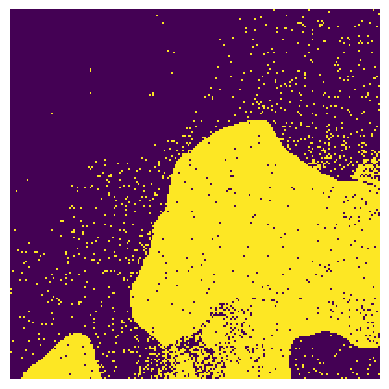

Stim_for_model/face/ 6 face (17).png


80000it [03:57, 336.59it/s]
80000it [02:26, 546.71it/s]


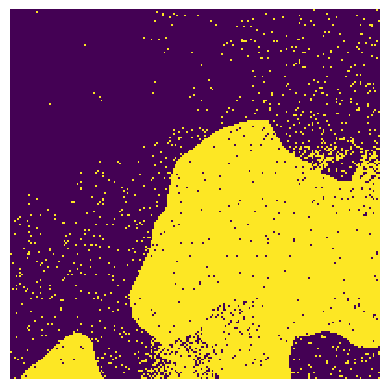

Stim_for_model/face/ 7 face (18).png


80000it [04:01, 330.90it/s]
80000it [02:22, 559.79it/s]


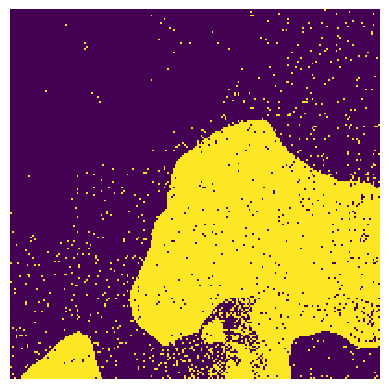

Stim_for_model/face/ 8 face (2).png


80000it [03:54, 340.54it/s]
80000it [02:24, 555.36it/s]


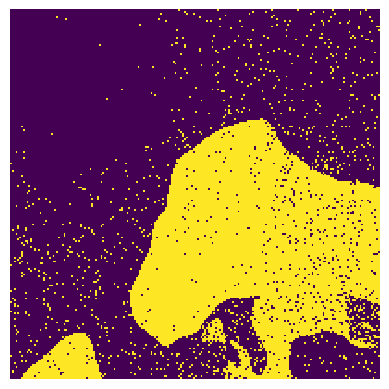

Stim_for_model/face/ 9 face (23).png


80000it [03:59, 334.20it/s]
80000it [02:19, 575.26it/s]


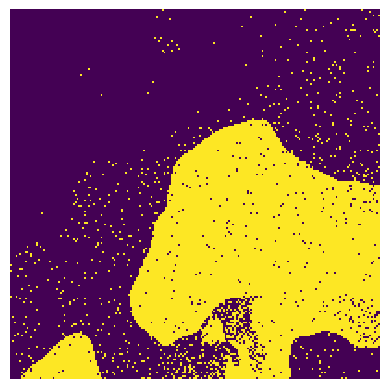

Stim_for_model/face/ 10 face (24).png


80000it [03:54, 341.16it/s] 
80000it [02:20, 567.82it/s]


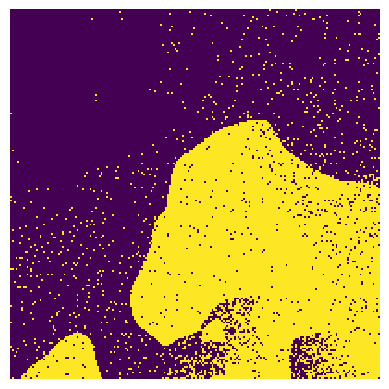

Stim_for_model/face/ 11 face (25).png


80000it [03:45, 354.19it/s]
80000it [02:16, 585.24it/s] 


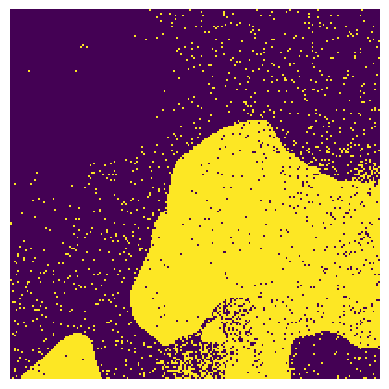

Stim_for_model/face/ 12 face (3).png


80000it [03:51, 344.84it/s]
80000it [02:11, 606.20it/s] 


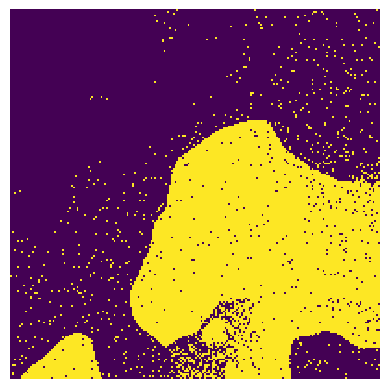

Stim_for_model/face/ 13 face (4).png


80000it [03:53, 341.89it/s]
80000it [02:05, 635.25it/s]


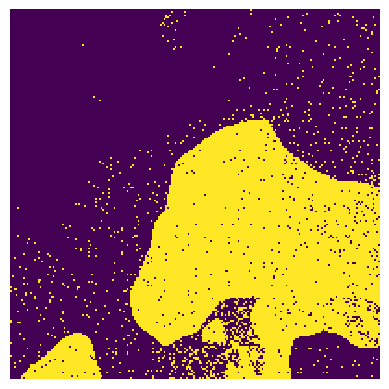

Stim_for_model/face/ 14 face (5).png


80000it [03:41, 361.23it/s]
80000it [02:12, 603.21it/s]


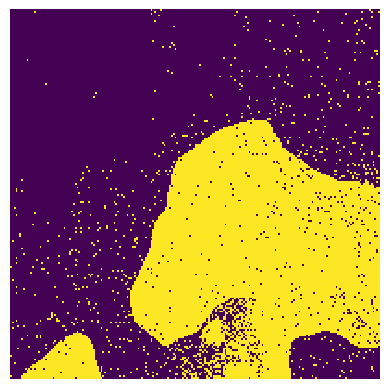

Stim_for_model/face/ 15 face (6).png


80000it [03:52, 343.98it/s]
80000it [02:27, 542.78it/s]


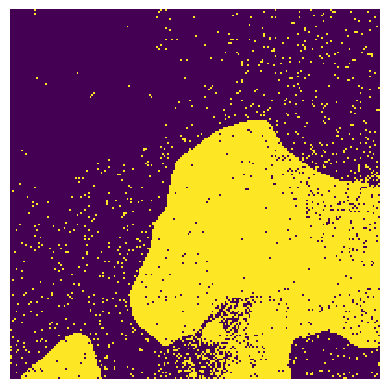

Stim_for_model/face/ 16 face (7).png


80000it [04:07, 323.46it/s]
80000it [02:24, 552.64it/s]


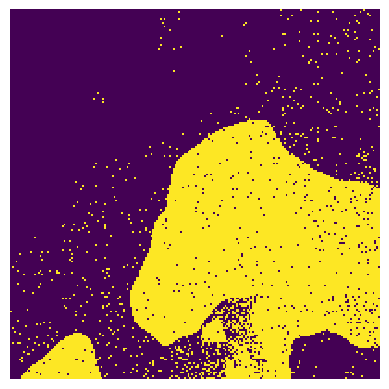

Stim_for_model/face/ 17 face (9).png


80000it [03:55, 339.31it/s]
80000it [02:23, 559.21it/s]


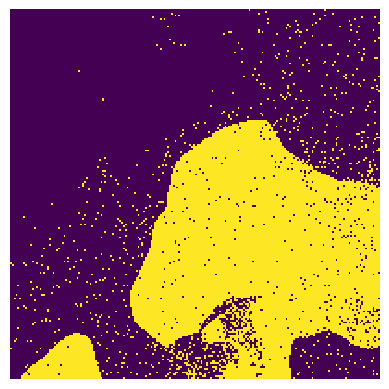

Stim_for_model/face/ 18 face (12).png


80000it [04:05, 326.15it/s]
80000it [02:26, 545.79it/s]


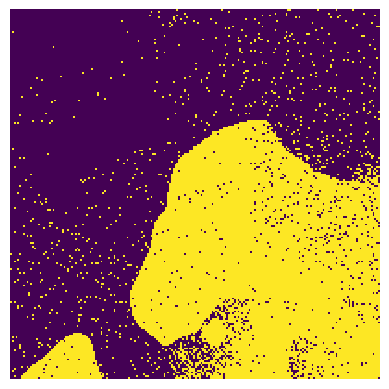

Stim_for_model/face/ 19 face (20).png


80000it [03:55, 339.73it/s]
80000it [02:18, 579.52it/s]


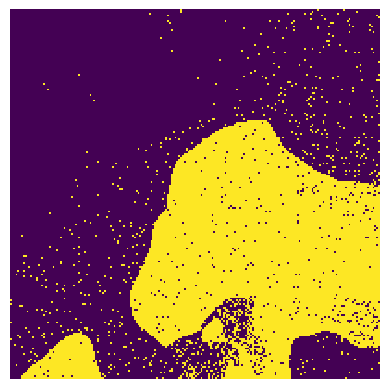

Stim_for_model/top_face/ 0 top_face (1).png


80000it [03:59, 334.34it/s]
80000it [02:24, 552.09it/s]


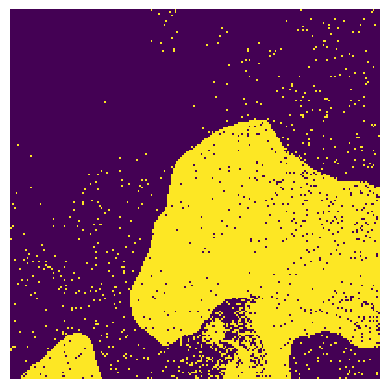

Stim_for_model/top_face/ 1 top_face (10).png


80000it [03:55, 340.16it/s]
80000it [02:13, 598.65it/s] 


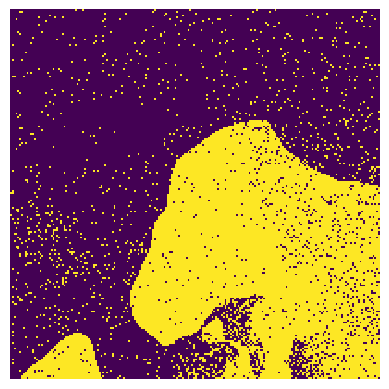

Stim_for_model/top_face/ 2 top_face (11).png


80000it [03:49, 349.24it/s]
80000it [02:20, 569.83it/s]


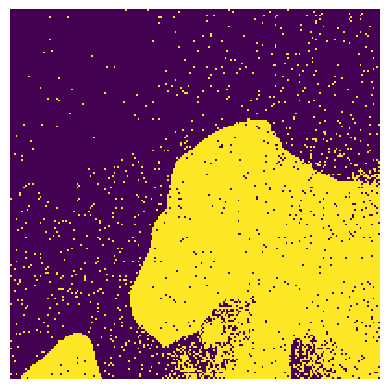

Stim_for_model/top_face/ 3 top_face (12).png


80000it [03:55, 339.56it/s]
80000it [02:26, 544.74it/s]


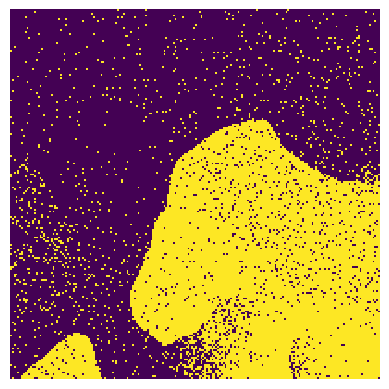

Stim_for_model/top_face/ 4 top_face (13).png


80000it [03:56, 338.71it/s]
80000it [02:23, 556.67it/s]


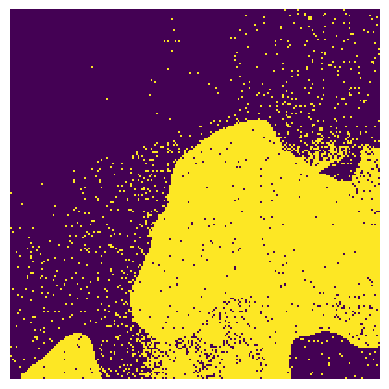

Stim_for_model/top_face/ 5 top_face (14).png


80000it [03:47, 352.23it/s]
80000it [02:30, 530.26it/s] 


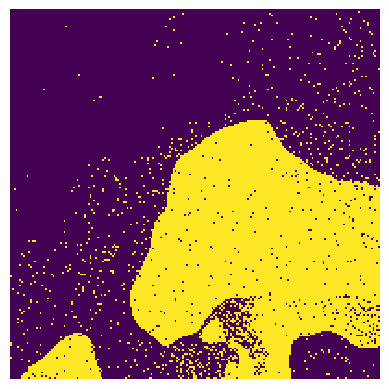

Stim_for_model/top_face/ 6 top_face (15).png


80000it [04:07, 322.66it/s]
80000it [02:24, 554.34it/s]


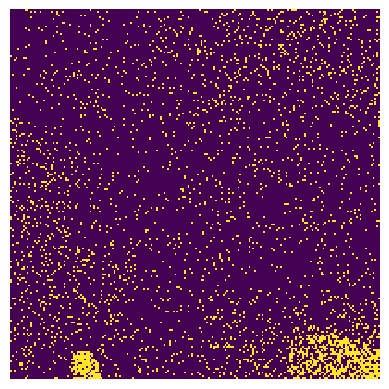

Stim_for_model/top_face/ 7 top_face (16).png


80000it [04:05, 325.55it/s]
80000it [02:17, 582.93it/s] 


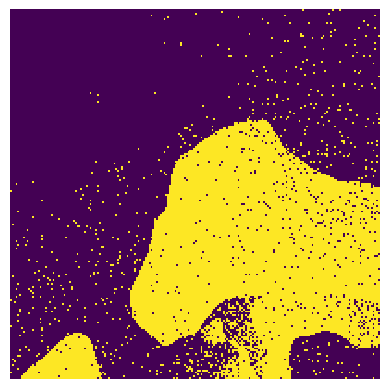

Stim_for_model/top_face/ 8 top_face (17).png


80000it [04:07, 323.01it/s]
80000it [02:23, 559.21it/s] 


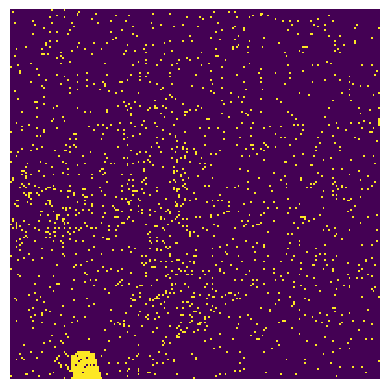

Stim_for_model/top_face/ 9 top_face (18).png


80000it [04:01, 331.40it/s]
80000it [02:25, 549.53it/s]


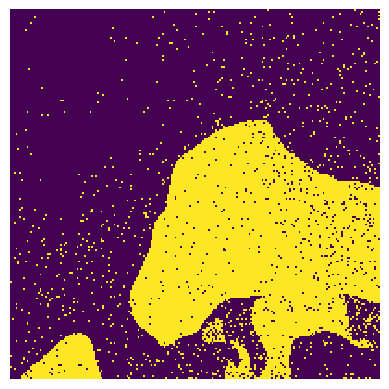

Stim_for_model/top_face/ 10 top_face (19).png


80000it [03:51, 346.31it/s]
80000it [02:16, 586.66it/s]


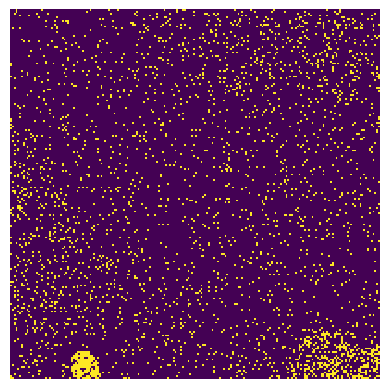

Stim_for_model/top_face/ 11 top_face (2).png


80000it [03:56, 337.75it/s]
80000it [02:19, 572.72it/s]


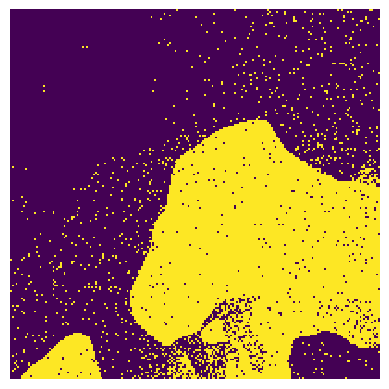

Stim_for_model/top_face/ 12 top_face (20).png


80000it [04:01, 331.91it/s]
80000it [02:18, 578.29it/s]


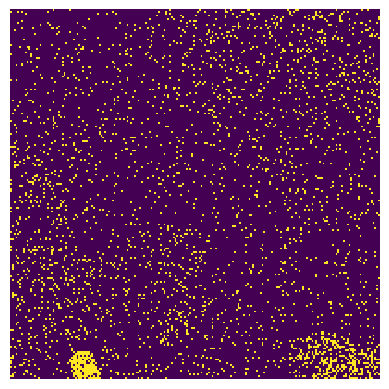

Stim_for_model/top_face/ 13 top_face (3).png


80000it [03:52, 343.89it/s]
80000it [02:14, 596.30it/s]


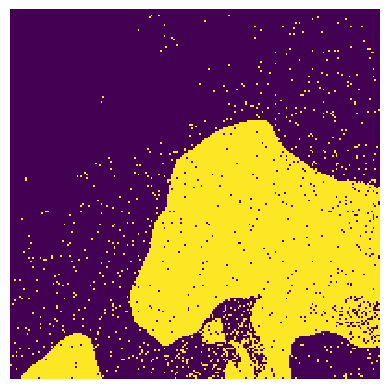

Stim_for_model/top_face/ 14 top_face (4).png


80000it [03:55, 339.97it/s] 
80000it [02:24, 555.31it/s]


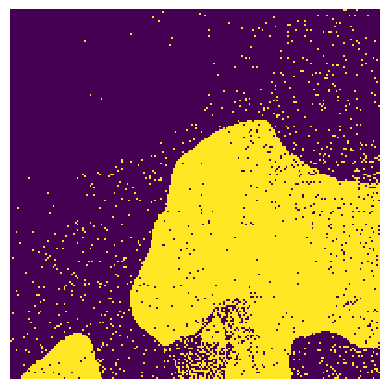

Stim_for_model/top_face/ 15 top_face (5).png


80000it [03:57, 336.68it/s]
80000it [02:28, 540.26it/s]


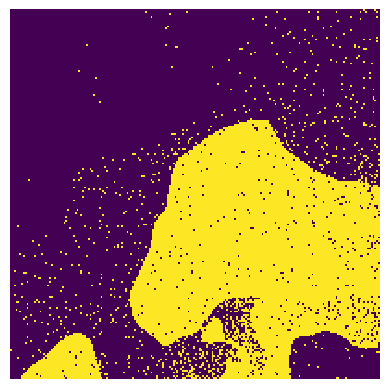

Stim_for_model/top_face/ 16 top_face (6).png


80000it [03:59, 333.82it/s]
80000it [02:21, 566.42it/s]


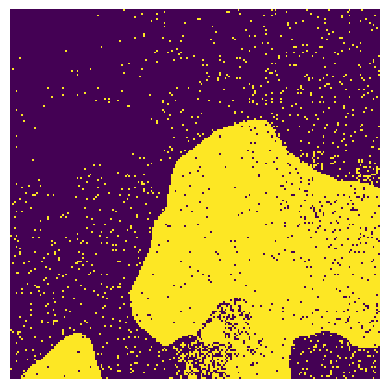

Stim_for_model/top_face/ 17 top_face (7).png


80000it [03:54, 341.62it/s]
80000it [02:27, 541.57it/s]


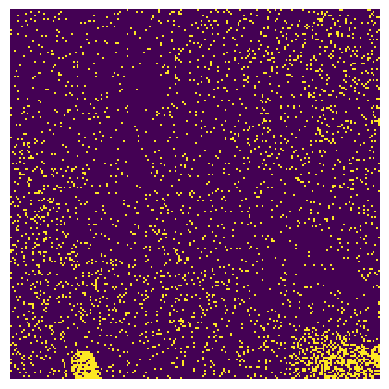

Stim_for_model/top_face/ 18 top_face (8).png


80000it [03:59, 333.52it/s]
80000it [02:20, 568.69it/s] 


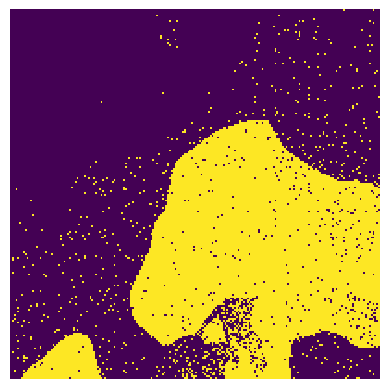

Stim_for_model/top_face/ 19 top_face (9).png


80000it [03:53, 342.33it/s]
80000it [02:15, 589.83it/s] 


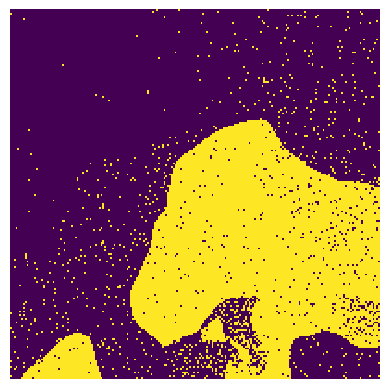

Stim_for_model/noeye/ 0 noeye (1).png


80000it [03:37, 367.64it/s]
80000it [02:18, 577.49it/s]


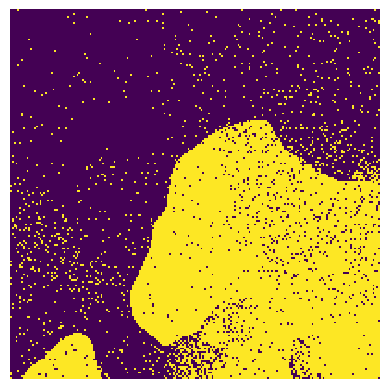

Stim_for_model/noeye/ 1 noeye (11).png


80000it [03:30, 379.70it/s] 
80000it [02:15, 590.11it/s]


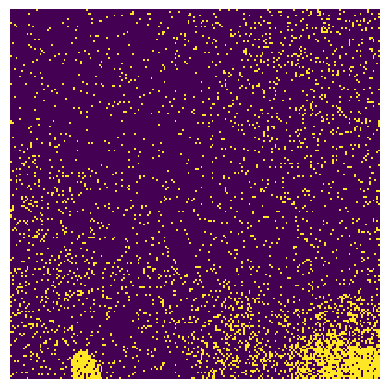

Stim_for_model/noeye/ 2 noeye (12).png


80000it [03:39, 365.20it/s]
80000it [02:22, 559.51it/s]


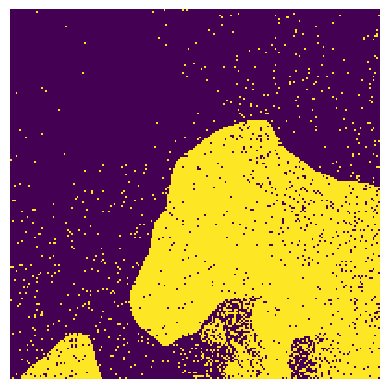

Stim_for_model/noeye/ 3 noeye (13).png


80000it [03:49, 348.14it/s]
80000it [02:19, 573.19it/s]


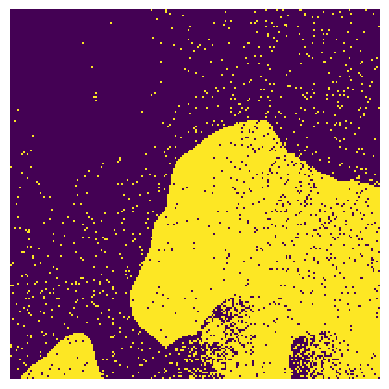

Stim_for_model/noeye/ 4 noeye (16).png


80000it [03:59, 333.40it/s]
80000it [02:26, 545.23it/s]


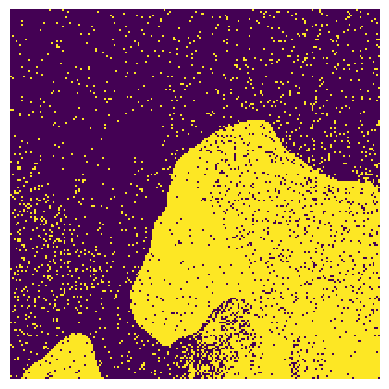

Stim_for_model/noeye/ 5 noeye (2).png


80000it [04:04, 326.96it/s]
80000it [02:17, 580.58it/s] 


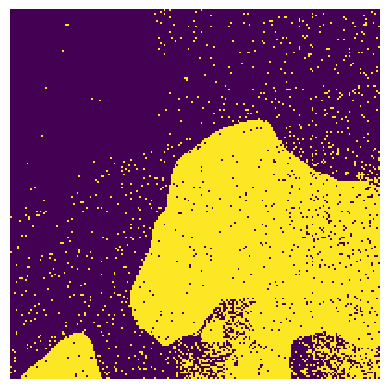

Stim_for_model/noeye/ 6 noeye (21).png


80000it [03:44, 356.78it/s]
80000it [02:19, 575.14it/s]


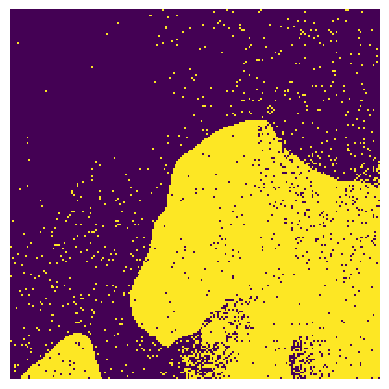

Stim_for_model/noeye/ 7 noeye (23).png


80000it [03:57, 336.19it/s]
80000it [02:17, 580.40it/s]


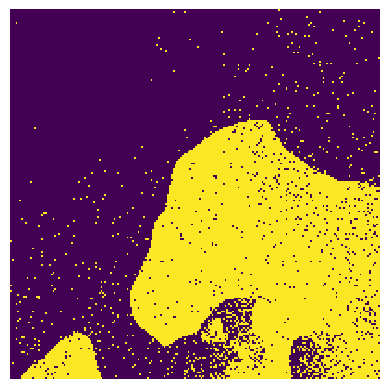

Stim_for_model/noeye/ 8 noeye (29).png


80000it [03:52, 343.69it/s]
80000it [02:24, 553.06it/s]


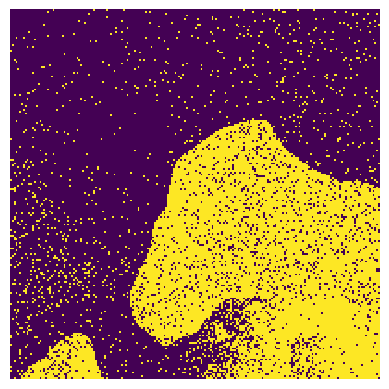

Stim_for_model/noeye/ 9 noeye (30).png


80000it [03:55, 338.99it/s]
80000it [02:18, 577.78it/s] 


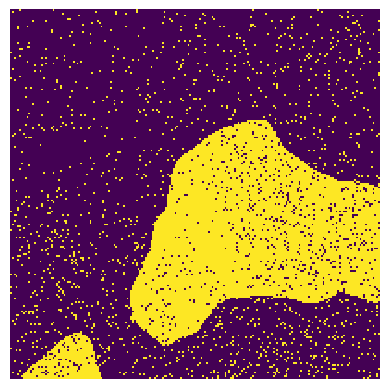

Stim_for_model/noeye/ 10 noeye (34).png


80000it [03:57, 337.09it/s]
80000it [02:21, 563.84it/s]


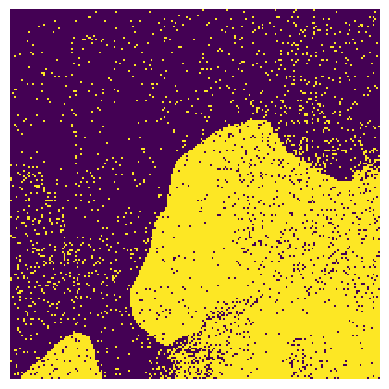

Stim_for_model/noeye/ 11 noeye (37).png


80000it [03:53, 342.48it/s]
80000it [02:21, 566.38it/s] 


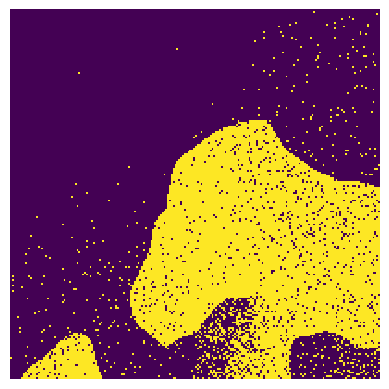

Stim_for_model/noeye/ 12 noeye (39).png


80000it [03:57, 336.91it/s]
80000it [02:06, 631.62it/s] 


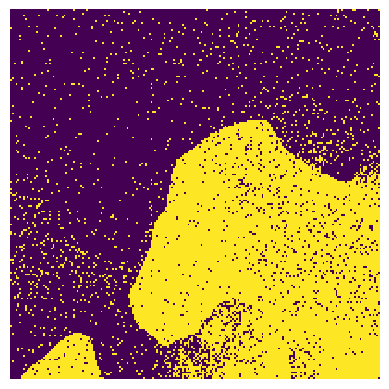

Stim_for_model/noeye/ 13 noeye (4).png


80000it [03:48, 349.88it/s]
80000it [02:17, 581.10it/s]


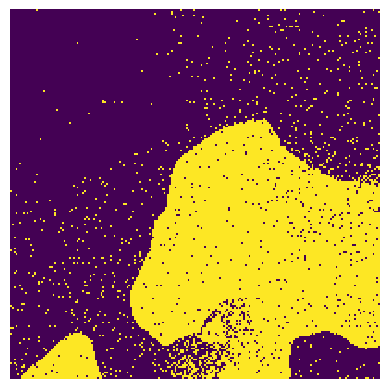

Stim_for_model/noeye/ 14 noeye (41).png


80000it [03:45, 354.57it/s]
80000it [02:11, 609.19it/s]


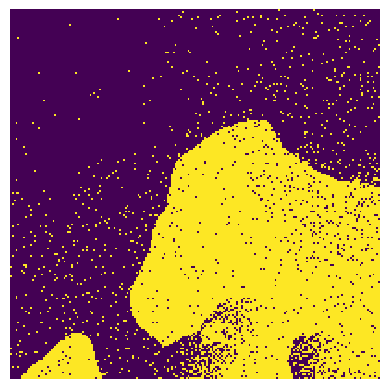

Stim_for_model/noeye/ 15 noeye (5).png


80000it [03:43, 358.24it/s]
80000it [02:10, 615.29it/s] 


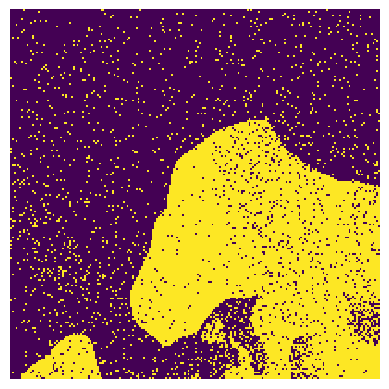

Stim_for_model/noeye/ 16 noeye (6).png


80000it [03:49, 348.30it/s]
80000it [02:18, 579.44it/s] 


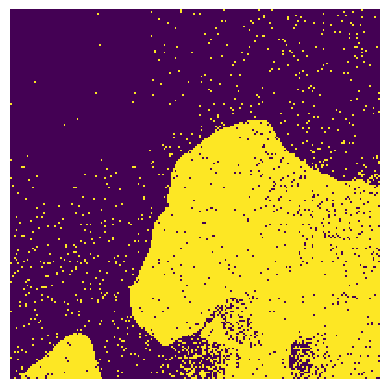

Stim_for_model/noeye/ 17 noeye (7).png


80000it [03:52, 344.25it/s]
80000it [02:29, 533.51it/s]


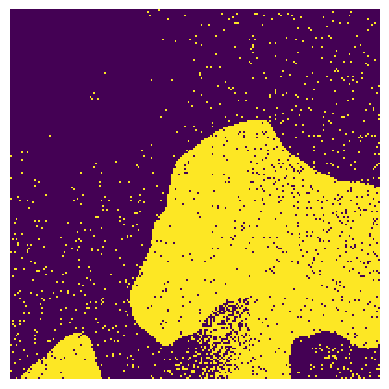

Stim_for_model/noeye/ 18 noeye (8).png


80000it [04:03, 328.38it/s]
80000it [02:13, 598.56it/s] 


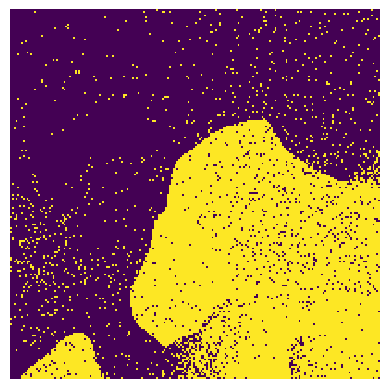

Stim_for_model/noeye/ 19 noeye (9).png


80000it [03:50, 347.73it/s]
80000it [02:15, 589.85it/s] 


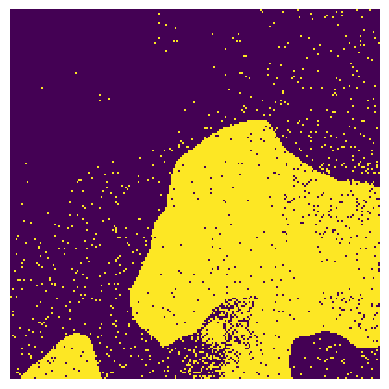

Stim_for_model/eyes/ 0 eyes (1).png


80000it [03:42, 359.90it/s]
80000it [02:19, 575.35it/s]


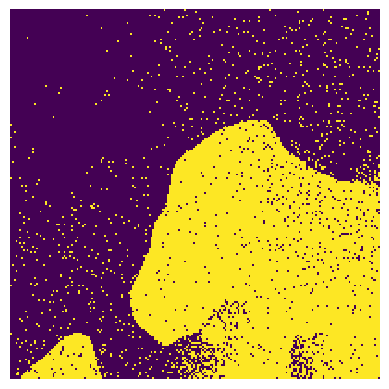

Stim_for_model/eyes/ 1 eyes (10).png


80000it [03:29, 382.07it/s]
80000it [02:21, 564.54it/s]


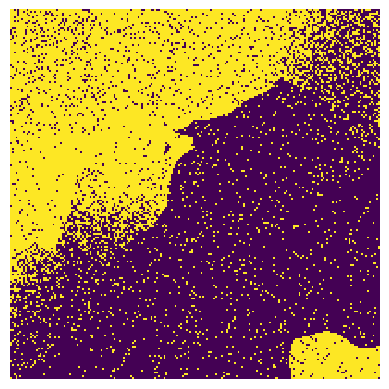

Stim_for_model/eyes/ 2 eyes (11).png


80000it [03:45, 355.53it/s]
80000it [02:06, 630.29it/s] 


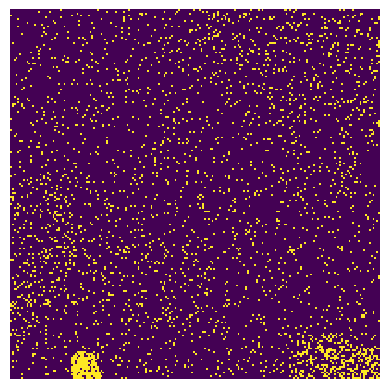

Stim_for_model/eyes/ 3 eyes (12).png


80000it [03:36, 369.03it/s]
80000it [02:28, 539.92it/s]


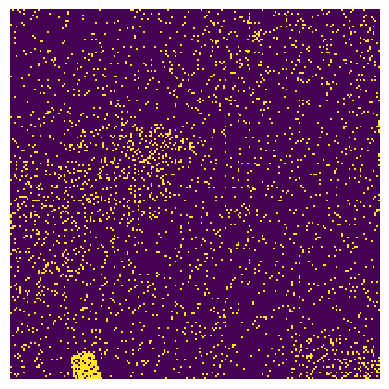

Stim_for_model/eyes/ 4 eyes (13).png


80000it [03:51, 345.81it/s]
80000it [02:10, 612.40it/s]


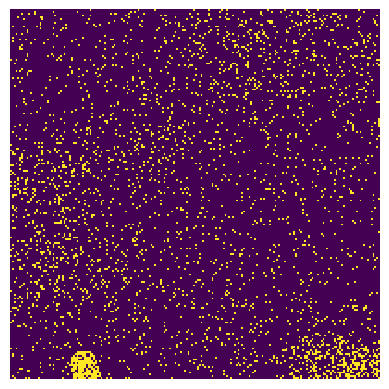

Stim_for_model/eyes/ 5 eyes (14).png


80000it [03:55, 339.02it/s]
80000it [02:24, 554.85it/s]


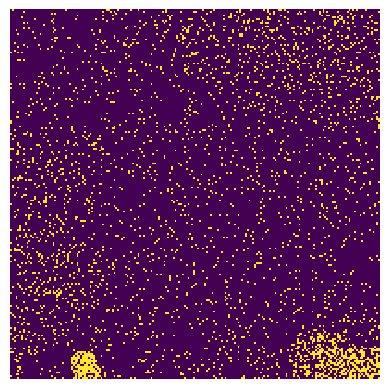

Stim_for_model/eyes/ 6 eyes (15).png


80000it [03:51, 345.00it/s]
80000it [02:17, 581.54it/s]


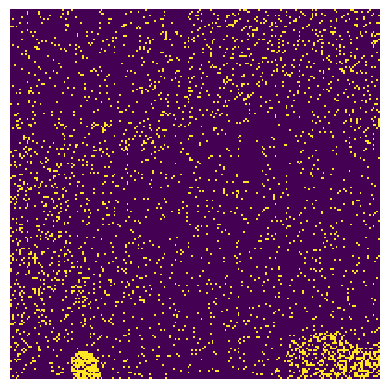

Stim_for_model/eyes/ 7 eyes (16).png


80000it [03:50, 347.13it/s]
80000it [02:20, 567.65it/s]


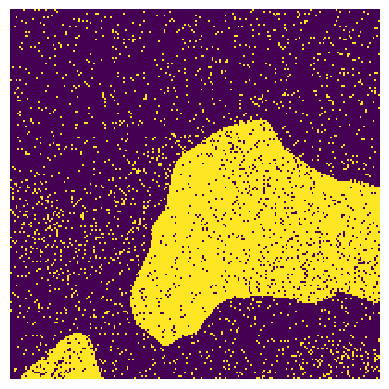

Stim_for_model/eyes/ 8 eyes (17).png


80000it [03:41, 360.62it/s]
80000it [02:11, 607.73it/s]


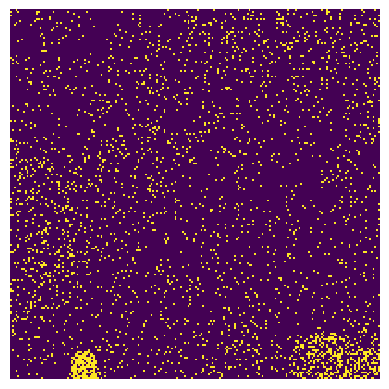

Stim_for_model/eyes/ 9 eyes (18).png


80000it [03:39, 365.22it/s]
80000it [02:07, 627.35it/s]


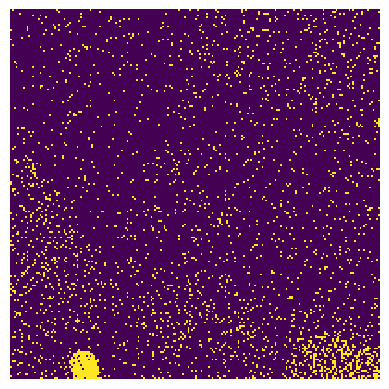

Stim_for_model/eyes/ 10 eyes (19).png


80000it [03:39, 365.15it/s]
80000it [02:02, 652.45it/s]


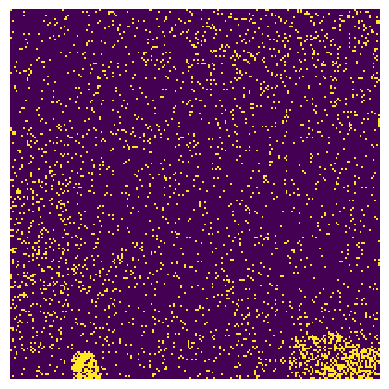

Stim_for_model/eyes/ 11 eyes (2).png


80000it [03:27, 385.68it/s]
80000it [01:43, 773.22it/s] 


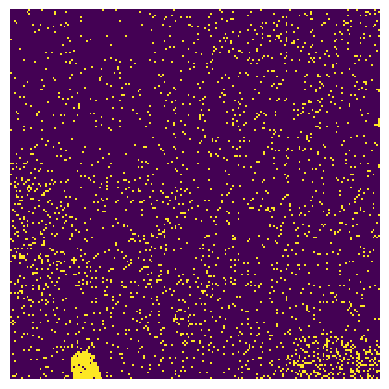

Stim_for_model/eyes/ 12 eyes (20).png


80000it [03:24, 391.94it/s]
80000it [01:55, 695.50it/s]


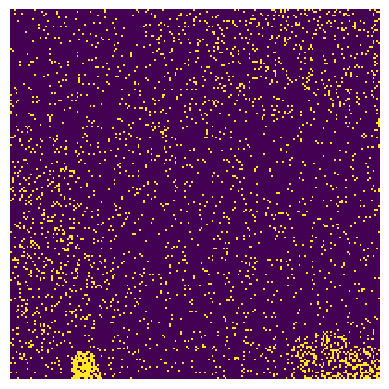

Stim_for_model/eyes/ 13 eyes (3).png


80000it [03:35, 371.62it/s]
80000it [02:07, 629.55it/s] 


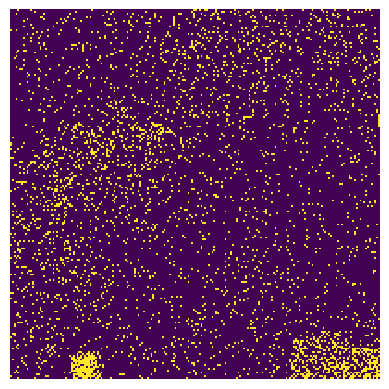

Stim_for_model/eyes/ 14 eyes (4).png


80000it [03:49, 349.31it/s]
80000it [02:15, 588.35it/s]


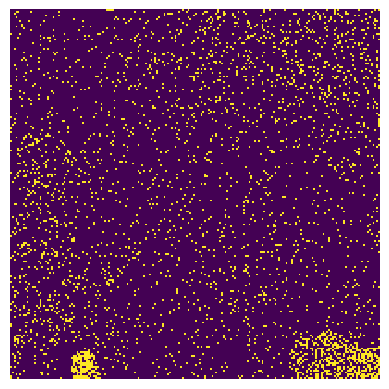

Stim_for_model/eyes/ 15 eyes (5).png


80000it [03:50, 347.54it/s]
80000it [02:08, 621.62it/s]


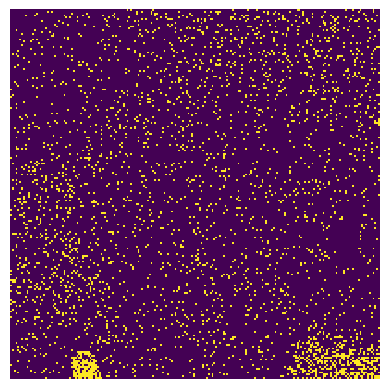

Stim_for_model/eyes/ 16 eyes (6).png


80000it [03:23, 393.24it/s]
80000it [02:02, 652.12it/s]


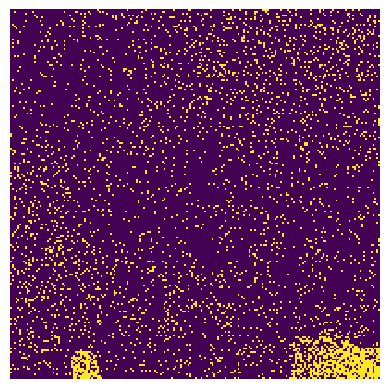

Stim_for_model/eyes/ 17 eyes (7).png


80000it [03:32, 376.28it/s]
80000it [02:15, 588.49it/s]


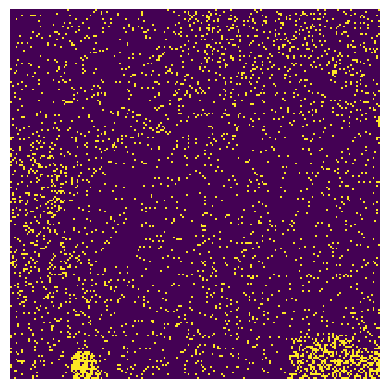

Stim_for_model/eyes/ 18 eyes (8).png


80000it [04:09, 321.28it/s]
80000it [02:19, 574.79it/s]


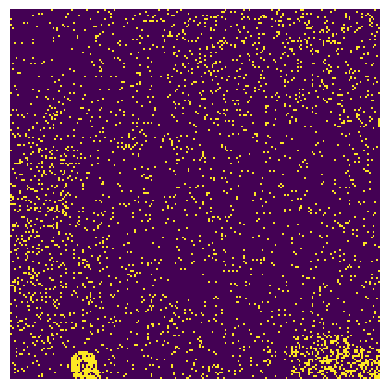

Stim_for_model/eyes/ 19 eyes (9).png


80000it [03:58, 334.99it/s]
80000it [02:23, 559.17it/s]


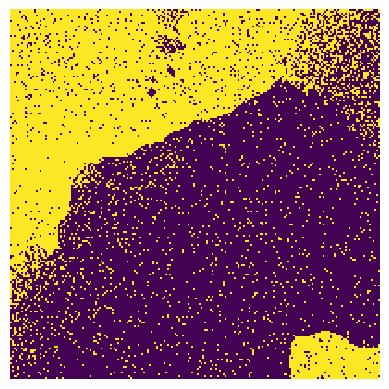

Stim_for_model/down_face/ 0 down_face (1).png


80000it [03:54, 340.89it/s]
80000it [02:27, 541.49it/s]


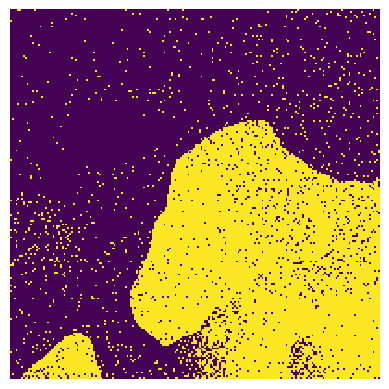

Stim_for_model/down_face/ 1 down_face (11).png


80000it [03:48, 349.80it/s]
80000it [02:19, 572.37it/s]


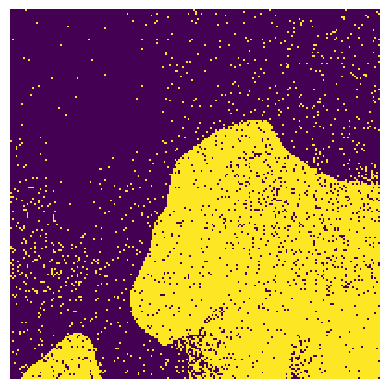

Stim_for_model/down_face/ 2 down_face (13).png


80000it [03:54, 340.47it/s]
80000it [02:24, 554.35it/s]


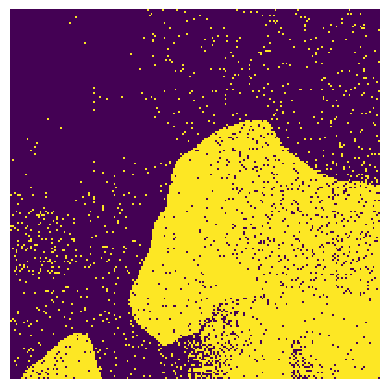

Stim_for_model/down_face/ 3 down_face (14).png


80000it [03:58, 334.96it/s]
80000it [02:25, 548.23it/s]


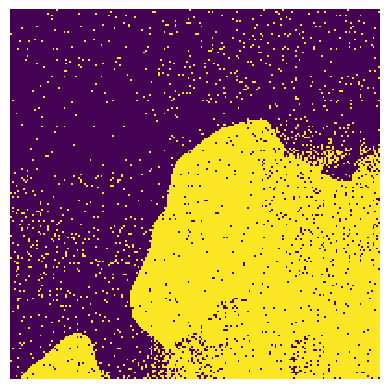

Stim_for_model/down_face/ 4 down_face (15).png


80000it [03:48, 350.84it/s]
80000it [02:24, 554.89it/s]


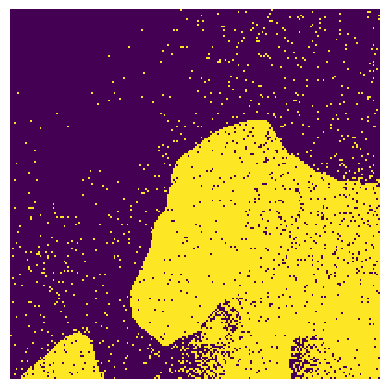

Stim_for_model/down_face/ 5 down_face (17).png


80000it [04:04, 327.19it/s]
80000it [02:23, 555.95it/s]


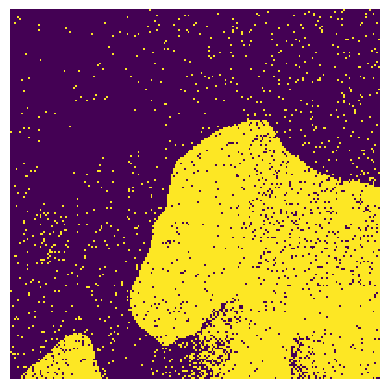

Stim_for_model/down_face/ 6 down_face (19).png


80000it [04:04, 327.49it/s]
80000it [02:25, 550.37it/s]


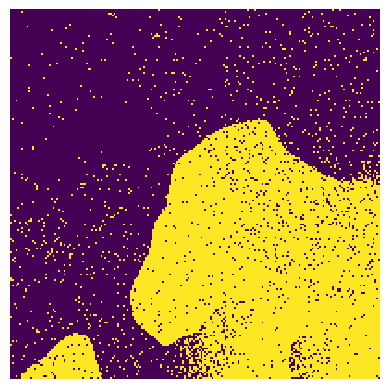

Stim_for_model/down_face/ 7 down_face (20).png


80000it [03:57, 336.93it/s]
80000it [02:21, 564.22it/s] 


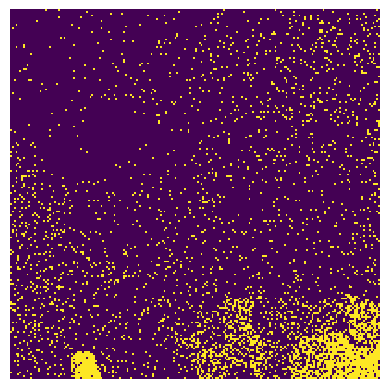

Stim_for_model/down_face/ 8 down_face (22).png


80000it [04:05, 325.74it/s]
80000it [02:22, 561.97it/s] 


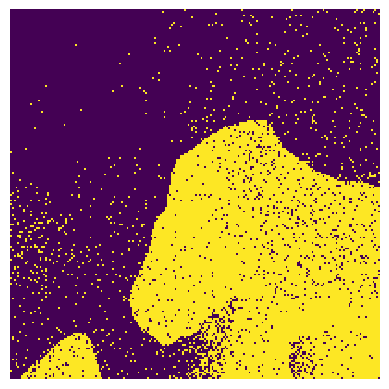

Stim_for_model/down_face/ 9 down_face (24).png


80000it [03:58, 334.90it/s] 
80000it [02:30, 532.00it/s]


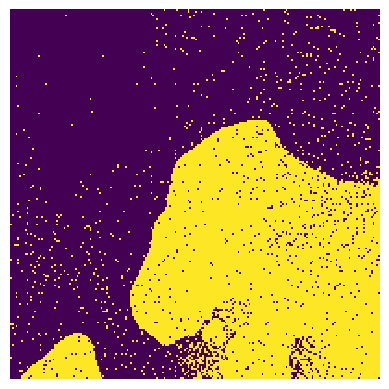

Stim_for_model/down_face/ 10 down_face (27).png


80000it [04:01, 330.71it/s] 
80000it [02:17, 580.83it/s]


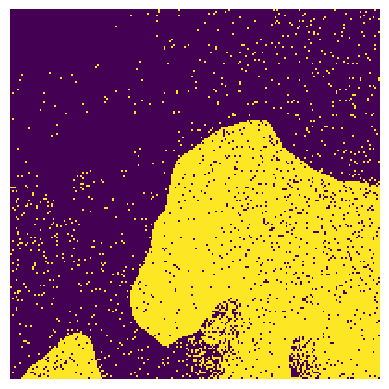

Stim_for_model/down_face/ 11 down_face (28).png


80000it [03:51, 345.00it/s]
80000it [02:19, 572.93it/s]


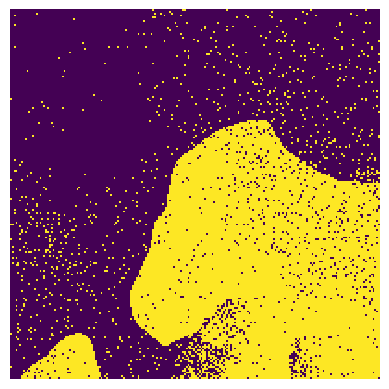

Stim_for_model/down_face/ 12 down_face (3).png


80000it [03:39, 364.66it/s]
80000it [02:21, 566.66it/s]


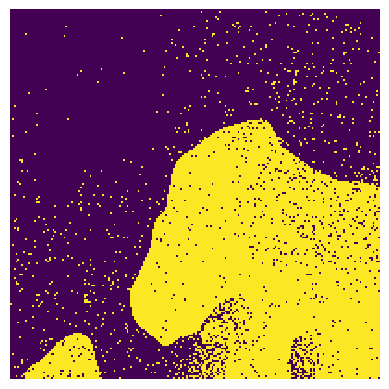

Stim_for_model/down_face/ 13 down_face (30).png


80000it [04:01, 331.26it/s]
80000it [02:26, 544.25it/s]


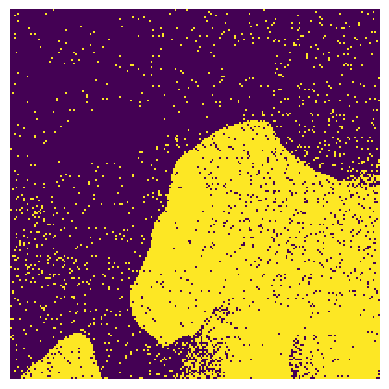

Stim_for_model/down_face/ 14 down_face (35).png


80000it [03:54, 341.62it/s]
80000it [02:22, 561.78it/s]


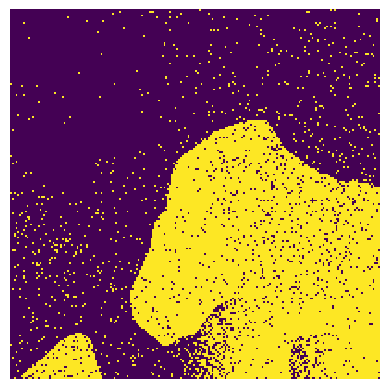

Stim_for_model/down_face/ 15 down_face (36).png


80000it [03:48, 350.82it/s]
80000it [02:21, 565.29it/s]


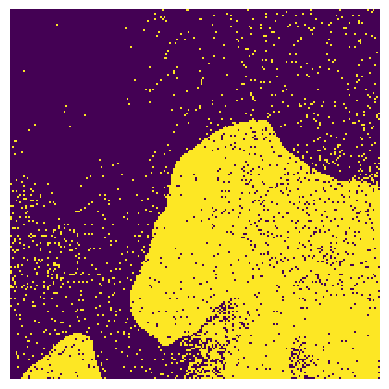

Stim_for_model/down_face/ 16 down_face (40).png


80000it [03:53, 341.96it/s]
80000it [02:13, 598.62it/s] 


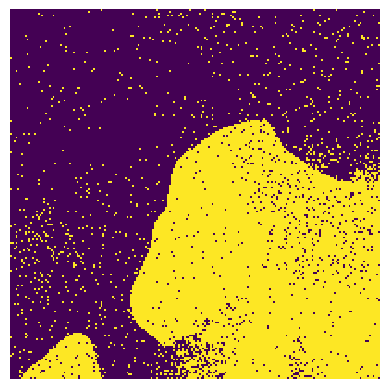

Stim_for_model/down_face/ 17 down_face (9).png


80000it [03:56, 337.92it/s]
80000it [02:22, 559.68it/s] 


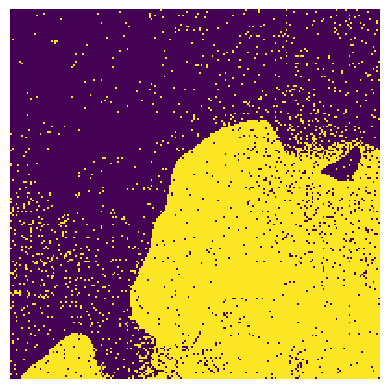

Stim_for_model/down_face/ 18 face (21).png


80000it [04:00, 332.82it/s]
80000it [02:23, 559.37it/s]


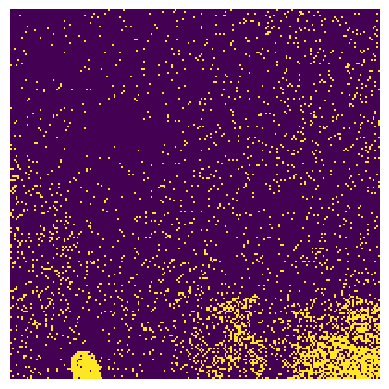

Stim_for_model/down_face/ 19 face (39).png


80000it [04:02, 330.19it/s] 
80000it [02:19, 571.99it/s]


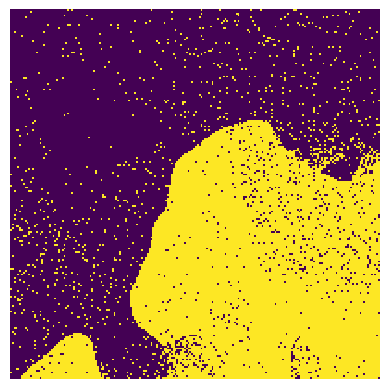

In [ ]:
mode = 'feedback'
pid_dir = 'Stim_for_model/'
save_dir = 'VTC_vlPFC_model/'

if mode=='feedback':
    method = Feedback_results
    
    images_response,Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all = method(pid_dir+'face/', mean,std)
    results = results_dic([Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all], mode)
    with open(save_dir+'Face_'+mode+'_results.npy', 'wb') as f:
        pickle.dump(results, f, protocol=5)
    
    images_response,Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all = method(pid_dir+'top_face/', mean,std)
    results = results_dic([Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all], mode)
    with open(save_dir+'Top_face_'+mode+'_results.npy', 'wb') as f:
        pickle.dump(results, f, protocol=5)
    
    images_response,Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all = method(pid_dir+'noeye/', mean,std)
    results = results_dic([Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all], mode)
    with open(save_dir+'Noeye_'+mode+'_results.npy', 'wb') as f:
        pickle.dump(results, f, protocol=5)
    
    images_response,Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all = method(pid_dir+'eyes/', mean,std)
    results = results_dic([Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all], mode)
    with open(save_dir+'Eyes_'+mode+'_results.npy', 'wb') as f:
        pickle.dump(results, f, protocol=5)
    
    images_response,Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all = method(pid_dir+'down_face/', mean,std)
    results = results_dic([Dynamic_states_VTC, Dynamic_states_vlPFC, F_all, H_top_down_all], mode)
    with open(save_dir+'Down_face_'+mode+'_results.npy', 'wb') as f:
        pickle.dump(results, f, protocol=5)

In [18]:
Dynamics_states_feedback_VTC = load_Dynamics_state('model_results/', 'feedback', 'Dynamic_states_VTC')

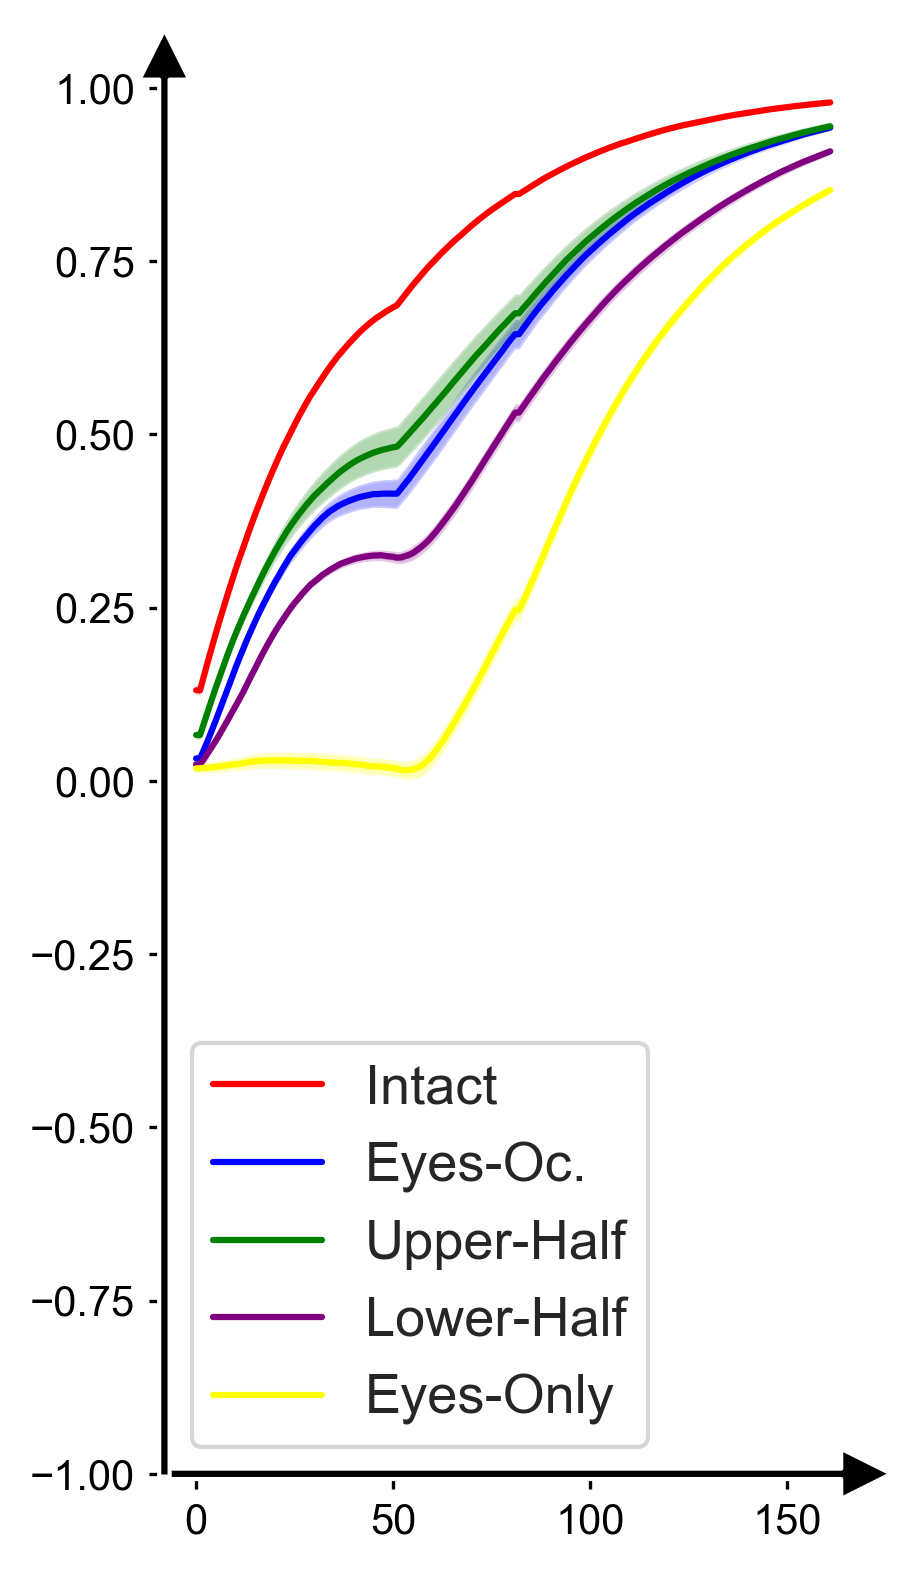

In [21]:
plot_6_condition_timeseries(mode='double', region='face', Dynamics_states=Dynamics_states_feedback_VTC)

# Energy surface vlPFC

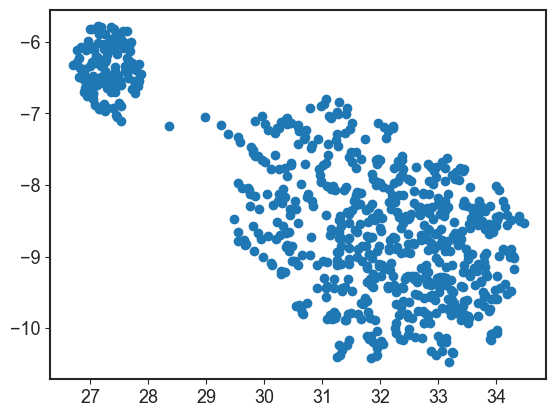

In [24]:
%matplotlib inline

from umap import UMAP
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
from scipy import interpolate
import warnings
warnings.filterwarnings('ignore')
clist=['Black','Grey']
newcmap = LinearSegmentedColormap.from_list('chaos',clist)

X_vlPFC = np.load('X_vlPFC.npy')
X_vlPFC_embedded = UMAP(n_components=2,n_neighbors=200).fit_transform(X_vlPFC.reshape(-1,400))

plt.figure()
plt.scatter(X_vlPFC_embedded[:,0], X_vlPFC_embedded[:,1])

In [27]:
def plot_surface(X_embedded, H, e):
    def transfer_H(H):
        H = np.where(H>0, 0, H)
        H = -np.power(-H, 0.5)    
        return H
    def fake_point(X_embedded,p,q):
        X_fake = []
        np.random.seed(0)
        for i in np.random.uniform(p,q,(100,2)):
            d_min = np.linalg.norm(X_embedded-i, axis=1).min()
            if d_min>3:
                X_fake.append(i)
        X_fake = np.array(X_fake)
        H_fake = np.zeros(X_fake.shape[0])
        return X_fake, H_fake
    def low_pass_filter(znew, width):
        f = np.fft.fft2(znew) 
        fshift = np.fft.fftshift(f)
        rows, cols = znew.shape
        crow, ccol = int(rows/2) , int(cols/2)     # ÖÐÐÄÎ»ÖÃ        
        # µÍÍ¨ÂË²¨
        mask = np.zeros((rows, cols), np.uint8)
        mask[crow-width:crow+width, ccol-width:ccol+width] = 1
        # IDFT
        fshift = fshift*mask
        f_ishift = np.fft.ifftshift(fshift)
        znew_back = np.fft.ifft2(f_ishift)
        znew_back = -np.abs(znew_back)
        return znew_back
    # plot
    H = transfer_H(H)
    min_value = -50
    # generate fake point
    a,b = [np.floor(X_embedded[:,0].min()-e),np.ceil(X_embedded[:,0].max()+e)]
    c,d = [np.floor(X_embedded[:,1].min()-e),np.ceil(X_embedded[:,1].max()+e)]
    X_fake, H_fake = fake_point(X_embedded,p=min(a,c),q=max(b,d))
    # surface fit
    func = interpolate.Rbf(np.hstack((X_embedded[:,0],X_fake[:,0])),
                           np.hstack((X_embedded[:,1],X_fake[:,1])),
                           np.hstack((H,H_fake)), function='multiquadric', smooth=0.1)
    xnew,ynew = np.mgrid[a:b:0.5,c:d:0.5]
    znew = func(xnew,ynew)
    #znew = low_pass_filter(znew, width=8)
    fig = plt.figure(figsize=(5,5), dpi=150)
    ax = Axes3D(fig)
    ax.plot_surface(xnew,ynew,znew, cmap='YlGn_r', alpha=0.7,rstride=1, cstride=1)
    ax.contour(xnew,ynew,znew, zdir='z',
               levels=[znew.min()*0.8, znew.min()*0.7, znew.min()*0.6], 
               offset=min_value, cmap=newcmap, linewidths=1)
    ax.set_zlim([min_value,0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.patch.set_facecolor("white")
    return xnew,ynew,znew

In [28]:
H_vlPFC_feedback = np.load('H_vlPFC_feedback.npy')[:,:,np.arange(0,30,5)].reshape(-1)
print('load H and X_embedded is ok')

xnew,ynew,znew = plot_surface(X_vlPFC_embedded, H_vlPFC_feedback, e=5)

load H and X_embedded is ok


<Figure size 750x750 with 0 Axes>

In [31]:
def plot_points_in_surface(xnew,ynew,znew, x_embedded, h):
    def transfer_H(H):
        H = np.where(H>0, 0, H)
        H = -np.power(-H, 0.5)    
        return H
    # plot
    min_value = -50
    fig = plt.figure(figsize=(5,5), dpi=150)
    ax = Axes3D(fig)
    ax.plot_surface(xnew,ynew,znew, cmap='YlGn_r', alpha=0.7,rstride=1, cstride=1)
    t_start = x_embedded.shape[1]-1
    t_end = x_embedded.shape[1]
    s = 50
    for i in np.arange(0,20,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='red', alpha=(t+1)/t_end)
    for i in np.arange(20,40,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='green', alpha=(t+1)/t_end)
    for i in np.arange(40,60,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='blue', alpha=(t+1)/t_end)
    for i in np.arange(60,80,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='purple', alpha=(t+1)/t_end)
    for i in np.arange(80,100,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='yellow', alpha=(t+1)/t_end)
    for i in np.arange(100,120,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='black', alpha=(t+1)/t_end)
    ax.contour(xnew,ynew,znew, zdir='z',
               levels=[znew.min()*0.8, znew.min()*0.7, znew.min()*0.6], 
               offset=min_value, cmap=newcmap, linewidths=1)
    ax.set_zlim([min_value,0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.patch.set_facecolor("white")

In [32]:
plot_points_in_surface(xnew,ynew,znew, 
                       X_vlPFC_embedded.reshape(120,6,2), 
                       H_vlPFC_feedback.reshape(120,6))

<Figure size 750x750 with 0 Axes>

In [34]:
def plot_example_in_surface(xnew,ynew,znew, x_embedded, h):
    def transfer_H(H):
        H = np.where(H>0, 0, H)
        H = -np.power(-H, 0.5)    
        return H
    # plot
    min_value = -50
    fig = plt.figure(figsize=(5,5), dpi=200)
    ax = Axes3D(fig)
    ax.plot_surface(xnew,ynew,znew, cmap='YlGn_r', alpha=0.7,rstride=1, cstride=1)
    t_start = 0
    t_end = h.shape[0]
    s = 10
    for t in np.arange(t_start,t_end,1):
        ax.scatter(x_embedded[t,0],x_embedded[t,1],transfer_H(h[t]), s=s, color='red', alpha=1)
    ax.contour(xnew,ynew,znew, zdir='z',
               levels=[znew.min()*0.8, znew.min()*0.7, znew.min()*0.6], 
               offset=min_value, cmap=newcmap, linewidths=1)
    ax.set_zlim([min_value,0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.patch.set_facecolor("white")
    
pic_index = 90
x = X_vlPFC_embedded.reshape(120,6,2)[pic_index]
h = H_vlPFC_feedback.reshape(120,6)[pic_index]
plot_example_in_surface(xnew,ynew,znew, x[:],h[:])

<Figure size 1000x1000 with 0 Axes>

# Energy surface VTC

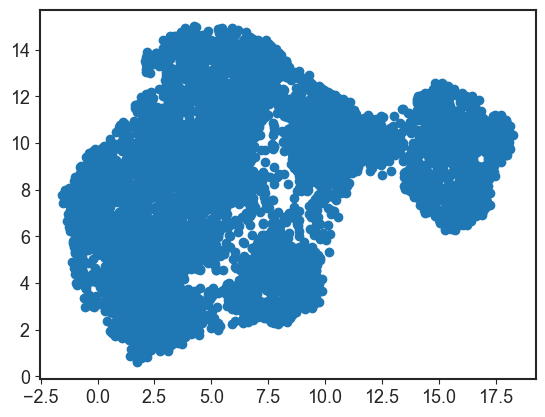

In [35]:
from umap import UMAP

X_VTC = np.load('X_VTC.npy')
X_VTC_embedded = UMAP(n_components=2,min_dist=1,n_neighbors=100).fit_transform(X_VTC.reshape(-1,40000))
plt.figure()
plt.scatter(X_VTC_embedded[:,0], X_VTC_embedded[:,1])

In [37]:
def plot_surface(X_embedded, H, e):
    def transfer_H(H):
        H = np.where(H>0, 0, H)
        H = -np.power(-H, 0.5)    
        return H
    def fake_point(X_embedded,p,q):
        X_fake = []
        np.random.seed(0)
        for i in np.random.uniform(p,q,(100,2)):
            d_min = np.linalg.norm(X_embedded-i, axis=1).min()
            if d_min>3:
                X_fake.append(i)
        X_fake = np.array(X_fake)
        H_fake = np.zeros(X_fake.shape[0])
        return X_fake, H_fake
    def low_pass_filter(znew, width):
        f = np.fft.fft2(znew) 
        fshift = np.fft.fftshift(f)
        rows, cols = znew.shape
        crow, ccol = int(rows/2) , int(cols/2)     # ÖÐÐÄÎ»ÖÃ        
        # µÍÍ¨ÂË²¨
        mask = np.zeros((rows, cols), np.uint8)
        mask[crow-width:crow+width, ccol-width:ccol+width] = 1
        # IDFT
        fshift = fshift*mask
        f_ishift = np.fft.ifftshift(fshift)
        znew_back = np.fft.ifft2(f_ishift)
        znew_back = -np.abs(znew_back)
        return znew_back
    # plot
    H = transfer_H(H)
    min_value = -200
    # generate fake point
    a,b = [np.floor(X_embedded[:,0].min()-e),np.ceil(X_embedded[:,0].max()+e)]
    c,d = [np.floor(X_embedded[:,1].min()-e),np.ceil(X_embedded[:,1].max()+e)]
    X_fake, H_fake = fake_point(X_embedded,p=min(a,c),q=max(b,d))
    # surface fit
    func = interpolate.Rbf(np.hstack((X_embedded[:,0],X_fake[:,0])),
                           np.hstack((X_embedded[:,1],X_fake[:,1])),
                           np.hstack((H,H_fake)), function='multiquadric', smooth=10)
    xnew,ynew = np.mgrid[a:b:0.1,c:d:0.1]
    znew = func(xnew,ynew)
    #znew = low_pass_filter(znew, width=8)
    fig = plt.figure(figsize=(5,5), dpi=300)
    ax = Axes3D(fig)
    ax.plot_surface(xnew,ynew,znew, cmap='YlGn_r', alpha=0.7,rstride=1, cstride=1)
    ax.contour(xnew,ynew,znew, zdir='z',
               levels=[znew.min()*0.8, znew.min()*0.7, znew.min()*0.6], 
               offset=min_value, cmap=newcmap, linewidths=1)
    ax.set_zlim([min_value,0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.patch.set_facecolor("white")
    return xnew,ynew,znew,func

In [38]:
H_VTC_recurrent = np.load('H_VTC_recurrent.npy').reshape(-1)
H_VTC_feedback = np.load('H_VTC_feedback.npy').reshape(-1)
H_VTC = np.hstack((H_VTC_recurrent, H_VTC_feedback))
print('load H and X_embedded is ok')

xnew,ynew,znew,func = plot_surface(X_VTC_embedded, H_VTC, e=5)

load H and X_embedded is ok


<Figure size 1500x1500 with 0 Axes>

In [39]:
def plot_points_in_surface(xnew,ynew,znew, x_embedded, h):
    def transfer_H(H):
        H = np.where(H>0, 0, H)
        H = -np.power(-H, 0.5)    
        return H
    # plot
    min_value = -200
    fig = plt.figure(figsize=(5,5), dpi=300)
    ax = Axes3D(fig)
    ax.plot_surface(xnew,ynew,znew, cmap='YlGn_r', alpha=0.7,rstride=1, cstride=1)
    t_start = x_embedded.shape[1]-1
    t_end = x_embedded.shape[1]
    s = 50
    for i in np.arange(0,20,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='red', alpha=(t+1)/t_end)
    for i in np.arange(20,40,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='green', alpha=(t+1)/t_end)
    for i in np.arange(40,60,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='blue', alpha=(t+1)/t_end)
    for i in np.arange(60,80,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='purple', alpha=(t+1)/t_end)
    for i in np.arange(80,100,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='yellow', alpha=(t+1)/t_end)
    for i in np.arange(100,120,1):
        for t in np.arange(t_start,t_end,1):
            ax.scatter(x_embedded[i,t,0],x_embedded[i,t,1],transfer_H(h[i,t]), s=s, color='black', alpha=(t+1)/t_end)
    ax.contour(xnew,ynew,znew, zdir='z',
               levels=[znew.min()*0.8, znew.min()*0.7, znew.min()*0.6], 
               offset=min_value, cmap=newcmap, linewidths=1)
    ax.set_zlim([min_value,0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.patch.set_facecolor("white")

In [40]:
# VTC-only Energy landscape
plot_points_in_surface(xnew,ynew,znew, 
                       X_VTC_embedded[:3240].reshape(120,27,2), 
                       H_VTC_recurrent.reshape(120,27))

<Figure size 1500x1500 with 0 Axes>

In [42]:
def plot_example_in_surface(xnew,ynew,znew, x_embedded, h):
    def transfer_H(H):
        H = np.where(H>0, 0, H)
        H = -np.power(-H, 0.50)    
        return H
    # plot
    min_value = -200
    fig = plt.figure(figsize=(5,5), dpi=300)
    ax = Axes3D(fig)
    ax.plot_surface(xnew,ynew,znew, cmap='YlGn_r', alpha=0.7,rstride=1, cstride=1)
    t_start = 0
    t_end = h.shape[0]
    s = 20
    for t in np.arange(t_start,t_end,1):
        ax.scatter(x_embedded[t,0],x_embedded[t,1],transfer_H(h[t]), s=s, color='black', alpha=1)
    ax.contour(xnew,ynew,znew, zdir='z',
               levels=[znew.min()*0.8, znew.min()*0.7, znew.min()*0.6], 
               offset=min_value, cmap=newcmap, linewidths=1)
    ax.set_zlim([min_value,0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.patch.set_facecolor("white")
    
pic_index = 96
x = X_VTC_embedded[:3240].reshape(120,27,2)[pic_index]
h = H_VTC_recurrent.reshape(120,27)[pic_index]
plot_example_in_surface(xnew,ynew,znew, x[:],h[:])

<Figure size 1500x1500 with 0 Axes>

In [41]:
# VTC-vlPFC feedback Energy landscape
plot_points_in_surface(xnew,ynew,znew, 
                       X_VTC_embedded[3240:].reshape(120,33,2), 
                       H_VTC_feedback.reshape(120,33))

<Figure size 1500x1500 with 0 Axes>

In [43]:
def plot_example_in_surface(xnew,ynew,znew, x_embedded, h):
    def transfer_H(H):
        H = np.where(H>0, 0, H)
        H = -np.power(-H, 0.45)    
        return H
    # plot
    min_value = -200
    fig = plt.figure(figsize=(5,5), dpi=300)
    ax = Axes3D(fig)
    ax.plot_surface(xnew,ynew,znew, cmap='YlGn_r', alpha=0.7,rstride=1, cstride=1)
    s = 20
    for t in np.arange(0,10,1):
        ax.scatter(x_embedded[t,0],x_embedded[t,1],transfer_H(h[t]), s=s, color='black', alpha=1)
    for t in np.arange(10,16,1):
        ax.scatter(x_embedded[t,0],x_embedded[t,1],transfer_H(h[t]), s=s, color='red', alpha=1)
    for t in np.arange(16,33,1):
        ax.scatter(x_embedded[t,0],x_embedded[t,1],transfer_H(h[t]), s=s, color='black', alpha=1)
    ax.contour(xnew,ynew,znew, zdir='z',
               levels=[znew.min()*0.8, znew.min()*0.7, znew.min()*0.6], 
               offset=min_value, cmap=newcmap, linewidths=1)
    ax.set_zlim([min_value,0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.patch.set_facecolor("white")

x = X_VTC_embedded[3240:].reshape(120,33,2)[pic_index]
h = H_VTC_feedback.reshape(120,33)[pic_index]
plot_example_in_surface(xnew,ynew,znew, x[:],h[:])

<Figure size 1500x1500 with 0 Axes>